# SNLP Assignment 6

Name 1: <br>
Student id 1: <br>
Email 1: <br>

Name 2: <br>
Student id 2:  <br>
Email 2:  <br>

Name 3: <br>
Student id 3:  <br>
Email 3: <br>

**Instructions:**
- Read each question carefully.
- Make sure you appropriately comment your code wherever required.
- Your final submission should contain the completed Notebook and the respective Python files for any additional exercises necessary.
- There is no need to submit the data files should they exist.
- Upload the zipped folder on CMS. Please follow the naming convention of 
**Name1_studentID1_Name2_studentID2_Name3_studentID3.zip**. Only one member of the group should make the submisssion.

**General guidelines:**
- Don't change the layout of the notebook, especially the final output cells. If you do end up changing the code, add comments to tell us why you needed to do it. Look out for **`#TODO`** to determine where to code.
- Use log with base 2 wherever you feel logarithimic operations are necessary. If you do use other bases, please specify it and explain why.
- See type hints to understand the args and return types for functions.

---

## Imports & Installs

In [1]:
# Required libraries
! pip install tqdm numpy matplotlib nltk tokenizers

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached numpy-2.4.6-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.9-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (52 kB)
  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
  Using cached contourpy-1.3.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached joblib-1.5.3-py3-none-

In [2]:
import os
from typing import List
from importlib import reload

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import nltk

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

import exercise_1

## Exercise 6.1.1: Interpolated N-gram Language Model *(3.5 points)*

An n-gram language model estimates the probability of a word given its preceding context. Higher-order models (e.g. trigrams) capture more context but suffer from data sparsity i.e. many n-grams are never seen in training. **Linear interpolation** addresses this by combining models of all orders from 1 up to $n$, weighting each equally at $\lambda = \frac{1}{n}$:

$$P_{\text{interp}}(w_i \mid w_{i-n+1}^{i-1}) = \lambda \sum_{k=1}^{n} P(w_i \mid w_{i-k+1}^{i-1})$$

This ensures that even unseen high-order n-grams receive probability mass from the lower-order (unigram, bigram, …) components. Each component probability is further smoothed using **add-$\alpha$ (Laplace) smoothing** to handle zero counts.

---

In `exercise_1.py`, implement the following:

**Corpus utilities**: work on the Penn Treebank corpus from `nltk`:
- `preprocess_tokenized_corpus`: cleans and filters an already-loaded tokenized corpus. (provided)
- `make_vocab`: build a vocabulary from the top-$k$ most frequent unigrams. *(0.25 points)*
- `restrict_vocab`: replace out-of-vocabulary words with `<unk>`. *(0.25 points)*
- `train_test_split`: split the corpus into train/test sets. *(1 point)*

**`Interpolated_Model` class**: initialized with $\alpha = 0$, $n = 2$, $\lambda = \frac{1}{n}$:
- `_get_n_grams`: (provided)
- `laplace_prob`: compute the add-$\alpha$ smoothed probability of an n-gram. *(0.5 points)*
- `interpolated_prob`: compute the linearly interpolated probability across all orders. *(1 point)*
- `perplexity`: evaluate the model on the test set. *(0.5 points)*

Once complete, report the perplexity for $\alpha = 0.0001$, $n = 3$.

In [6]:
exercise_1 = reload(exercise_1)

# Hyperparameters
ALPHA = 0.0001
N = 3

# Load the PTB corpus and preprocess it
nltk.download('treebank', quiet=True)
corpus = list(nltk.corpus.treebank.sents())
cleaned_corpus = exercise_1.preprocess_tokenized_corpus(corpus, max_ngram_order=N)

# Train-test split (using train_split ratio)
train_sents, test_sents = exercise_1.train_test_split(cleaned_corpus, train_split=0.7)


def get_perplexity(
    train_sents: List[List[str]],
    test_sents: List[List[str]],
    alpha: float,
    order: int,
    top_k: int
) -> float:
    '''
    Helper function to get perplexity using the interpolated model for given hyperparameters.
    Performs:
        - Vocabulary creation and restriction
        - Fit the interpolated model specified by the hyperparameters
        - Returns the perplexity of the model on the test set

    Hint: Reuse this function for Ex. 6.1.2.
    '''
    vocab = exercise_1.make_vocab(train_sents, top_k)
    restricted_train_sents = exercise_1.restrict_vocab(train_sents, vocab)
    restricted_test_sents = exercise_1.restrict_vocab(test_sents, vocab)
    model = exercise_1.InterpolatedModel(restricted_train_sents, restricted_test_sents, alpha=alpha, order=order)
    perplexity = model.perplexity()
    return perplexity


# Get perplexity
perplexity = get_perplexity(train_sents, test_sents, ALPHA, N, 1000)
print(f"Perplexity (α={ALPHA}, n={N}): {perplexity:.4f}")

Perplexity (α=0.0001, n=3): 50.8631


## Exercise 6.1.2: Hyperparameter Tuning using k-Fold Cross Validation *(2 points)*

**(a)** For the interpolated n-gram model, implement the `cross_validate` function below to find the optimal combination of n-gram order $n \in \{1,2,3,4,5\}$ and smoothing factor $\alpha \in \{0.0001, 0.001, 0.01, 0.1\}$ using 5-fold cross-validation. *(1 point)*

- You may reuse `get_perplexity` and `train_test_split` from Exercise 6.1.
- The code for plotting the results and printing the optimal hyperparameters is provided.

**(b)** What is the general trend for the perplexity curve as $n$ increases? Give reasons for the trend. *(0.5 points)*

**(c)** With different $\alpha$ values, how does the shape of the curve differ? Give reasons for the difference. (Feel free to try out different $\alpha$ values on your own to understand its nature better.) *(0.5 points)*

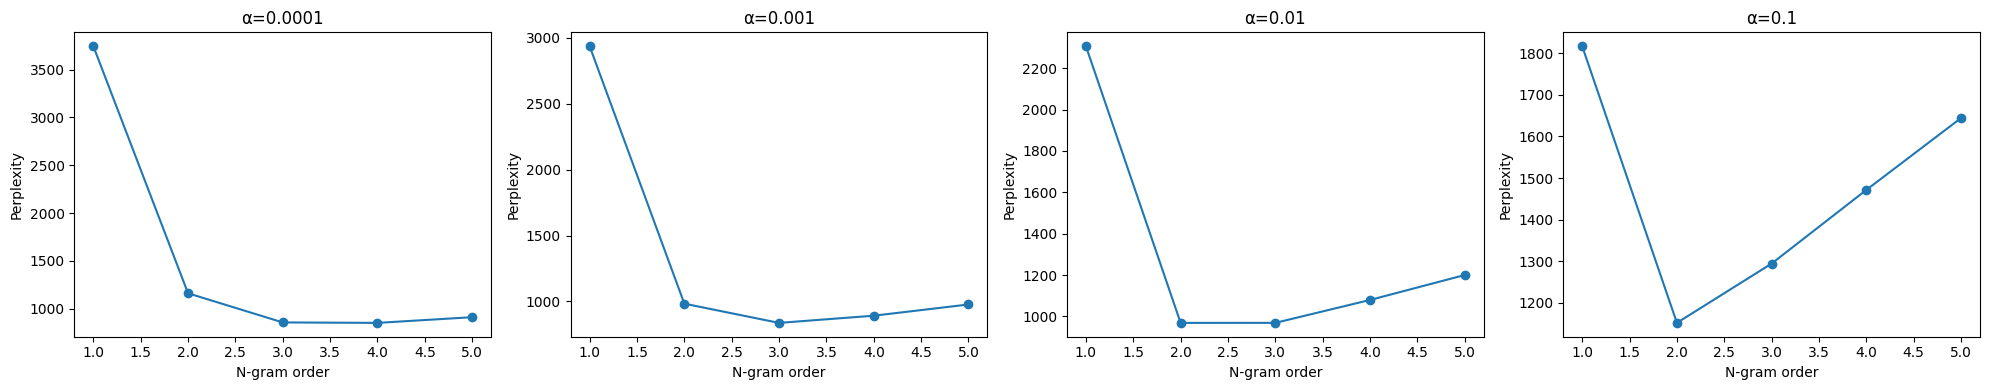

Optimal: n=3, α=0.001, perplexity=836.8868


In [7]:
exercise_1 = reload(exercise_1)

def cross_validate(
    corpus: List[List[str]],
    orders: List[int],
    alphas: List[float],
    num_folds: int
) -> dict:
    '''
    Cross-validation loop to evaluate perplexity for each combination of hyperparameters.
    Returns a nested dictionary results[alpha][order] = mean perplexity across folds.
    '''
    results = {alpha: {order: 0.0 for order in orders} for alpha in alphas}
    for alpha in alphas:
        for order in orders:
            fold_perplexities = []
            for fold in range(num_folds):
                train_sents, test_sents = exercise_1.train_test_split(corpus, num_folds=num_folds, fold=fold)
                model = exercise_1.InterpolatedModel(train_sents, test_sents, alpha=alpha, order=order)
                perplexity = model.perplexity()
                fold_perplexities.append(perplexity)
            mean_perplexity = sum(fold_perplexities) / len(fold_perplexities)
            results[alpha][order] = mean_perplexity
    return results


# Hyperparameters & NUM_FOLDS
ORDERS = [1, 2, 3, 4, 5]
ALPHAS = [0.0001, 0.001, 0.01, 0.1]
NUM_FOLDS = 5

# Get results
results = cross_validate(cleaned_corpus, ORDERS, ALPHAS, NUM_FOLDS)

# Plot results
fig, axes = plt.subplots(1, len(ALPHAS), figsize=(5 * len(ALPHAS), 4), squeeze=False)
for ax, alpha in zip(axes[0], ALPHAS):
    ppls = [results[alpha][o] for o in ORDERS]
    ax.plot(ORDERS, ppls, marker='o')
    ax.set(title=f'α={alpha}', xlabel='N-gram order', ylabel='Perplexity')
plt.tight_layout()
plt.show()

# Report optimal
best = min((results[a][o], o, a) for a in ALPHAS for o in ORDERS)
print(f"Optimal: n={best[1]}, α={best[2]}, perplexity={best[0]:.4f}")

In [ ]:
#TODO (b), (c)


**(b)** As n increases, perplexity decreases because higher-order n-grams capture more context, but eventually flattens or rises due to data sparsity making higher-order counts unreliable.

**(c)** High α → curve flattens earlier and at higher perplexity because heavy smoothing pushes probabilities toward uniform distribution.
Low α → curve decreases longer and reaches lower perplexity because light smoothing lets the raw counts dominate, making higher-order context genuinely useful.

## Exercise 6.2: Domain Mismatch in BPE Tokenization *(2.5 points)*

In this exercise you will investigate what happens when a BPE tokenizer is applied to text
from a **different domain** than the one it was trained on.

We use two corpora:
- **News domain:** Penn Treebank (`nltk.corpus.treebank`), which you already used in Exercise 6.1.
- **Medical domain:** Real-world clinical transcription notes from the MTSamples dataset
  ([Kaggle: tboyle10/medicaltranscriptions](https://www.kaggle.com/datasets/tboyle10/medicaltranscriptions)). Samples extracted into a plain-text corpus in `./data/medical_transcript_samples.txt`.

We use the HuggingFace `tokenizers` library for a fast BPE implementation.
To measure tokenization quality across domains we use **three metrics**:

- **OOV rate:** Fraction of words that encode to `[UNK]`, i.e. contain a character unseen during training.
- **Average tokens per word (Fertility):** Average number of subword pieces a word is split into.
  A value of 1.0 means every word is a single token. Higher values indicate more fragmentation.
- **Token split rate (TSR):** Fraction of words split into more than one subword piece.
  Directly measures how often the tokenizer fails to represent a word as a single unit.

---

**(a)** Load & preprocess both corpora. Create train/test splits. Code for training the BPE tokenizer has been provided.

**(b)** Implement `compute_oov_rate()`, `compute_avg_tokens_per_word()`, and `compute_tsr()`. *(1.5 points)*

**(c)** Train a BPE tokenizer on the `news_train` split and compute all three metrics on
(i) `news_test` and (ii) `med_test` splits. *(0.25 points)*

**(d)** Retrain a new BPE tokenizer on the `med_train` split and compute all three metrics
on the `med_test` split. *(0.25 points)*

**(e)** Based on the results, what can you say about the effect of domain mismatch on tokenization? *(0.25 points)*

**(f)** Which metrics were more useful than others in this case and why? *(0.25 points)*

In [9]:
corpus

[['Pierre',
  'Vinken',
  ',',
  '61',
  'years',
  'old',
  ',',
  'will',
  'join',
  'the',
  'board',
  'as',
  'a',
  'nonexecutive',
  'director',
  'Nov.',
  '29',
  '.'],
 ['Mr.',
  'Vinken',
  'is',
  'chairman',
  'of',
  'Elsevier',
  'N.V.',
  ',',
  'the',
  'Dutch',
  'publishing',
  'group',
  '.'],
 ['Rudolph',
  'Agnew',
  ',',
  '55',
  'years',
  'old',
  'and',
  'former',
  'chairman',
  'of',
  'Consolidated',
  'Gold',
  'Fields',
  'PLC',
  ',',
  'was',
  'named',
  '*-1',
  'a',
  'nonexecutive',
  'director',
  'of',
  'this',
  'British',
  'industrial',
  'conglomerate',
  '.'],
 ['A',
  'form',
  'of',
  'asbestos',
  'once',
  'used',
  '*',
  '*',
  'to',
  'make',
  'Kent',
  'cigarette',
  'filters',
  'has',
  'caused',
  'a',
  'high',
  'percentage',
  'of',
  'cancer',
  'deaths',
  'among',
  'a',
  'group',
  'of',
  'workers',
  'exposed',
  '*',
  'to',
  'it',
  'more',
  'than',
  '30',
  'years',
  'ago',
  ',',
  'researchers',
  'reported'

In [10]:
exercise_1 = reload(exercise_1)


# Load corpora as raw text for BPE training
news_text = "\n".join([" ".join(sent) for sent in corpus])
with open("./data/medical_transcript_samples.txt", "r", encoding="utf-8") as f:
    med_text = f.read()

# Train/test split (reuse your existing function)
news_train, news_test = exercise_1.train_test_split(news_text, train_split=0.7)
med_train, med_test  = exercise_1.train_test_split(med_text, train_split=0.7)


# Write train splits to temp files (HF trainer expects files)
if not os.path.exists("./tmp"):
    os.makedirs("./tmp")

with open("./tmp/news_train.txt", "w", encoding="utf-8") as f:
    f.write(news_train)
with open("./tmp/med_train.txt", "w", encoding="utf-8") as f:
    f.write(med_train)

def train_bpe(train_file: str, vocab_size: int) -> Tokenizer:
    '''
    Train a HuggingFace BPE tokenizer on the given training file and return the tokenizer object.
    '''
    tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
    tokenizer.pre_tokenizer = Whitespace()
    trainer = BpeTrainer(vocab_size=vocab_size, special_tokens=["[UNK]"])
    tokenizer.train([train_file], trainer)
    return tokenizer

news_tokenizer = train_bpe("./tmp/news_train.txt", vocab_size=1000)
med_tokenizer  = train_bpe("./tmp/med_train.txt", vocab_size=1000)

In [11]:
def get_tokens(tokenizer: Tokenizer, word: str) -> list:
    '''
    Returns a list of subword piece strings for a single word.
    '''
    return tokenizer.encode(word).tokens


def compute_oov_rate(tokenizer: Tokenizer, text: str) -> float:
    '''
    Compute the fraction of words that contain [UNK] tokens as subwords.
    '''
    words = text.strip().split()
    
    if len(words) == 0:
        return 0.0
    
    oov_count = 0
    for word in words:
        tokens = get_tokens(tokenizer, word)
        # Word is OOV if ANY token is [UNK]
        if "[UNK]" in tokens:
            oov_count += 1
    
    return oov_count / len(words)


def compute_avg_tokens_per_word(tokenizer: Tokenizer, text: str) -> float:
    '''
    Compute the average number of subword tokens produced per word (fertility).
    '''
    words = text.strip().split()
    
    if len(words) == 0:
        return 0.0
    
    total_tokens = 0
    for word in words:
        tokens = get_tokens(tokenizer, word)
        total_tokens += len(tokens)
    
    # Average tokens per word
    return total_tokens / len(words)


def compute_tsr(tokenizer: Tokenizer, text: str) -> float:
    '''
    Compute the token split rate (TSR): fraction of words split into more than one subword piece.
    '''
    words = text.strip().split()
    
    if len(words) == 0:
        return 0.0
    
    split_count = 0
    for word in words:
        tokens = get_tokens(tokenizer, word)
        # Word is split if it produces MORE than 1 token
        if len(tokens) > 1:
            split_count += 1
    
    return split_count / len(words)


# (c)
print('News tokenizer on news_test:')
print(f"  OOV:     {compute_oov_rate(news_tokenizer, news_test):.4f}")
print(f"  Avg tok: {compute_avg_tokens_per_word(news_tokenizer, news_test):.4f}")
print(f"  TSR:     {compute_tsr(news_tokenizer, news_test):.4f}")

print('\nNews tokenizer on med_test:')
print(f"  OOV:     {compute_oov_rate(news_tokenizer, med_test):.4f}")
print(f"  Avg tok: {compute_avg_tokens_per_word(news_tokenizer, med_test):.4f}")
print(f"  TSR:     {compute_tsr(news_tokenizer, med_test):.4f}")

# (d)
print('\nMedical tokenizer on med_test:')
print(f"  OOV:     {compute_oov_rate(med_tokenizer, med_test):.4f}")
print(f"  Avg tok: {compute_avg_tokens_per_word(med_tokenizer, med_test):.4f}")
print(f"  TSR:     {compute_tsr(med_tokenizer, med_test):.4f}")

News tokenizer on news_test:
  OOV:     0.0000
  Avg tok: 1.9305
  TSR:     0.4608

News tokenizer on med_test:
  OOV:     0.0014
  Avg tok: 2.6422
  TSR:     0.5644

Medical tokenizer on med_test:
  OOV:     0.0001
  Avg tok: 2.0479
  TSR:     0.4374


In [ ]:
#TODO (e), (f)
# E. News tokenizer on med_test showed higher OOV, avg tok, and TSR compared to the medical tokenizer, indicating it struggled more with the specialized medical vocabulary.
# F . TSR and avg tokens are the most useful metrics for diagnosing tokenizer performance. OOV rate only captures if a word is completely unknown, while TSR and avg tokens capture how well the tokenizer can represent words with subword pieces, which is crucial for handling rare or complex words.

## Exercise 6.3: Pruning with the Likelihood Criterion *(2 points)*

The change in likelihood for pruning a leaf node $(w, h)$ is defined as:

$$\Delta F_{\text{Leaf}} = N(w, h) \log \frac{P(w \mid h)}{\alpha(h)\,\beta(w \mid \hat{h})}$$

Given the following values for two bigram leaves:

| Leaf | $N(w,h)$ | $P(w \mid h)$ | $\alpha(h)$ | $\beta(w \mid \hat{h})$ |
|------|-----------|----------------|-------------|--------------------------|
| A: $P(\text{dog} \mid \text{the})$ | 80 | 0.04 | 0.1 | 0.05 |
| B: $P(\text{cat} \mid \text{the})$ | 10 | 0.06 | 0.1 | 0.05 |

**(a)** Compute $\Delta F_{\text{Leaf}}$ for both leaves (use $\log_2$). *(1 point)*

**(b)** Which leaf should be pruned first, and why? *(1 point)*

In [ ]:
#TODO (a), (b)


## (a) Computing $\Delta F_{\text{Leaf}}$

### Leaf A: $P(\text{dog} \mid \text{the})$

$$\alpha(h) \cdot \beta(w|\hat{h}) = 0.1 \times 0.05 = 0.005$$

$$\frac{P(w|h)}{\alpha(h)\cdot\beta(w|\hat{h})} = \frac{0.04}{0.005} = 8$$

$$\Delta F_A = 80 \cdot \log_2 8 = 80 \times 3 = \boxed{240}$$

### Leaf B: $P(\text{cat} \mid \text{the})$

$$\alpha(h) \cdot \beta(w|\hat{h}) = 0.1 \times 0.05 = 0.005$$

$$\frac{P(w|h)}{\alpha(h)\cdot\beta(w|\hat{h})} = \frac{0.06}{0.005} = 12$$

$$\Delta F_B = 10 \cdot \log_2 12 = 10 \times 3.585 = \boxed{35.85}$$

---

## (b) Which Leaf to Prune First?

**Prune Leaf B first** since $\Delta F_B = 35.85 \ll \Delta F_A = 240$, meaning it causes the least likelihood loss when removed.